# Student performance: early warning and support priorities
STDS 36103, Assessment Task 2 (group project). Code appendix.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score

RNG = 42

## 1. Data checks

In [2]:
df = pd.read_csv("student-por.csv")
df["fail"] = (df.G3 < 10).astype(int)
print("Shape:", df.shape, "| missing:", int(df.isna().sum().sum()), "| duplicates:", int(df.duplicated().sum()))
print("Sex:", df.sex.value_counts().to_dict(), "| age range:", df.age.min(), "to", df.age.max())
print("Failed (G3 < 10):", int(df.fail.sum()), f"({df.fail.mean():.1%})")
print("Mean G3:", round(df.G3.mean(), 2), "| median:", df.G3.median())

Shape: (649, 34) | missing: 0 | duplicates: 0
Sex: {'F': 383, 'M': 266} | age range: 15 to 22
Failed (G3 < 10): 100 (15.4%)
Mean G3: 11.91 | median: 12.0


Fifteen students have `G3 = 0`. All fifteen have zero absences and a non-zero term-1 grade, which points to students who did not sit the final exam.
We keep them in the analysis and count them as fails. Section 5 checks how much they affect the regression.

G3 = 0: 15 | absences = 0: 15 | G2 = 0: 7 | at school MS: 14


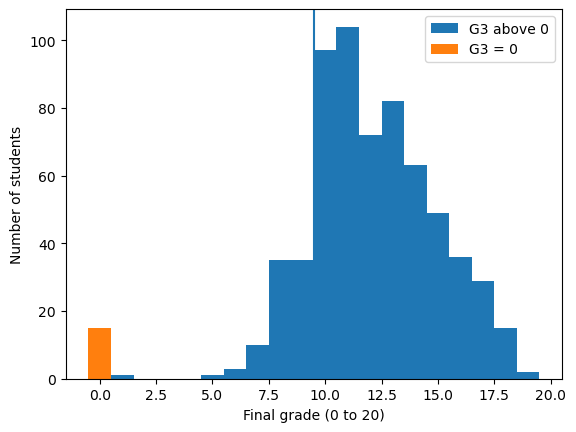

In [3]:
zero = df[df.G3 == 0]
print("G3 = 0:", len(zero), "| absences = 0:", int((zero.absences == 0).sum()), "| G2 = 0:", int((zero.G2 == 0).sum()), "| at school MS:", int((zero.school == "MS").sum()))
bins = np.arange(-0.5, 20.5, 1)
plt.hist(df.G3[df.G3 > 0], bins=bins, label="G3 above 0")
plt.hist(df.G3[df.G3 == 0], bins=bins, label="G3 = 0")
plt.axvline(9.5)
plt.xlabel("Final grade (0 to 20)")
plt.ylabel("Number of students")
plt.legend()
plt.show()

### Correlation table (numeric variables)

In [4]:
num = df.select_dtypes("number").drop(columns=["fail"])
corr = num.corr()
corr.round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.00,-0.11,-0.12,0.03,-0.01,0.32,-0.02,-0.00,0.11,0.13,0.09,-0.01,0.15,-0.17,-0.11,-0.11
Medu,-0.11,1.00,0.65,-0.27,0.10,-0.17,0.02,-0.02,0.01,-0.01,-0.02,0.00,-0.01,0.26,0.26,0.24
Fedu,-0.12,0.65,1.00,-0.21,0.05,-0.17,0.02,0.01,0.03,0.00,0.04,0.04,0.03,0.22,0.23,0.21
traveltime,0.03,-0.27,-0.21,1.00,-0.06,0.10,-0.01,0.00,0.06,0.09,0.06,-0.05,-0.01,-0.15,-0.15,-0.13
studytime,-0.01,0.10,0.05,-0.06,1.00,-0.15,-0.00,-0.07,-0.08,-0.14,-0.21,-0.06,-0.12,0.26,0.24,0.25
failures,0.32,-0.17,-0.17,0.10,-0.15,1.00,-0.06,0.11,0.05,0.11,0.08,0.04,0.12,-0.38,-0.39,-0.39
famrel,-0.02,0.02,0.02,-0.01,-0.00,-0.06,1.00,0.13,0.09,-0.08,-0.09,0.11,-0.09,0.05,0.09,0.06
freetime,-0.00,-0.02,0.01,0.00,-0.07,0.11,0.13,1.00,0.35,0.11,0.12,0.08,-0.02,-0.09,-0.11,-0.12
goout,0.11,0.01,0.03,0.06,-0.08,0.05,0.09,0.35,1.00,0.25,0.39,-0.02,0.09,-0.07,-0.08,-0.09
Dalc,0.13,-0.01,0.00,0.09,-0.14,0.11,-0.08,0.11,0.25,1.00,0.62,0.06,0.17,-0.20,-0.19,-0.20


In [5]:
corr["G3"].drop("G3").sort_values().round(2)

failures     -0.39
Dalc         -0.20
Walc         -0.18
traveltime   -0.13
freetime     -0.12
age          -0.11
health       -0.10
absences     -0.09
goout        -0.09
famrel        0.06
Fedu          0.21
Medu          0.24
studytime     0.25
G1            0.83
G2            0.92
Name: G3, dtype: float64

## 2. RQ1: does the term-1 grade (G1) warn us early? (logistic regression)

In [6]:
df["g1_low"] = (df.G1 < 10).astype(int)
ct = pd.crosstab(df.g1_low, df.fail)
print(ct)
tab = pd.DataFrame({"students": ct.sum(axis=1), "failed": ct[1], "fail_rate": (ct[1] / ct.sum(axis=1)).round(3)})
print(tab)
sens = ct.loc[1, 1] / ct[1].sum()
spec = ct.loc[0, 0] / ct[0].sum()
ppv = ct.loc[1, 1] / ct.loc[1].sum()
print(f"Share of fails with G1 < 10 (sensitivity): {sens:.1%} | specificity: {spec:.1%} | fail rate if G1 < 10: {ppv:.1%} | flagged: {ct.loc[1].sum()}")
r_g1 = stats.pearsonr(df.G1, df.G3)[0]
r_g2 = stats.pearsonr(df.G2, df.G3)[0]
print("Correlation with G3: G1 =", round(r_g1, 2), "| G2 =", round(r_g2, 2))

fail      0   1
g1_low         
0       480  12
1        69  88
        students  failed  fail_rate
g1_low                             
0            492      12      0.024
1            157      88      0.561
Share of fails with G1 < 10 (sensitivity): 88.0% | specificity: 87.4% | fail rate if G1 < 10: 56.1% | flagged: 157
Correlation with G3: G1 = 0.83 | G2 = 0.92


In [7]:
m_rq1 = smf.logit("fail ~ G1", data=df).fit(disp=0)
print(m_rq1.summary().tables[1])
odds = np.exp(m_rq1.params["G1"])
ci = np.exp(m_rq1.conf_int().loc["G1"])
print(f"Odds ratio per G1 point = {odds:.2f} (95% CI {ci[0]:.2f} to {ci[1]:.2f}), p = {m_rq1.pvalues['G1']:.2g}, McFadden R2 = {m_rq1.prsquared:.2f}")
auc_in = roc_auc_score(df.fail, m_rq1.predict(df))
oof = np.zeros(len(df))
for train, test in StratifiedKFold(10, shuffle=True, random_state=RNG).split(df, df.fail):
    model = smf.logit("fail ~ G1", data=df.iloc[train]).fit(disp=0)
    oof[test] = model.predict(df.iloc[test])
auc_cv = roc_auc_score(df.fail, oof)
print(f"AUC in sample = {auc_in:.3f}, 10-fold cross-validated = {auc_cv:.3f}")
probs = {}
for g in [8, 9, 10, 11]:
    probs[g] = round(float(m_rq1.predict(pd.DataFrame({"G1": [g]}))[0]), 3)
print(probs)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0119      1.077      9.294      0.000       7.900      12.123
G1            -1.2153      0.120    -10.165      0.000      -1.450      -0.981
Odds ratio per G1 point = 0.30 (95% CI 0.23 to 0.37), p = 2.8e-24, McFadden R2 = 0.51
AUC in sample = 0.947, 10-fold cross-validated = 0.941
{8: 0.572, 9: 0.284, 10: 0.105, 11: 0.034}


### Checks for the logistic model

Squared term: LR = 21.2, p = 4.1e-06
      n  observed  fitted
G1c                      
5     8     0.875   0.981
6     9     0.889   0.938
7    33     0.818   0.818
8    42     0.667   0.572
9    65     0.277   0.284
10   95     0.105   0.105
11   91     0.022   0.034
12   82     0.000   0.010
13   72     0.000   0.003
14   71     0.000   0.001
15   35     0.000   0.000
16   46     0.000   0.000


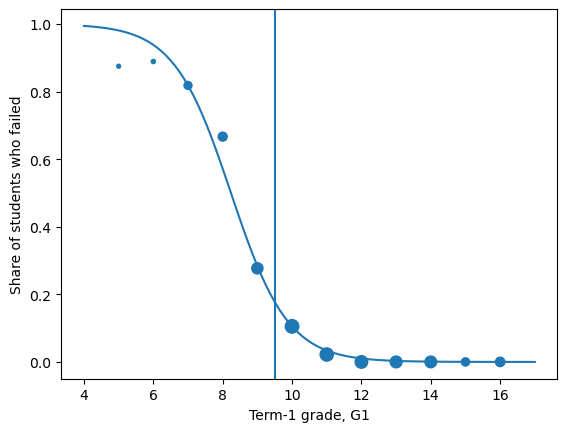

In [8]:
m_quad = smf.logit("fail ~ G1 + I(G1**2)", data=df).fit(disp=0)
lr = 2 * (m_quad.llf - m_rq1.llf)
p_lr = stats.chi2.sf(lr, 1)
print(f"Squared term: LR = {lr:.1f}, p = {p_lr:.2g}")
lv = df.assign(G1c=df.G1.clip(5, 16)).groupby("G1c").agg(n=("fail", "size"), observed=("fail", "mean"))
lv["fitted"] = m_rq1.predict(pd.DataFrame({"G1": lv.index})).values
print(lv.round(3))
xs = np.linspace(4, 17, 100)
plt.plot(xs, m_rq1.predict(pd.DataFrame({"G1": xs})))
plt.scatter(lv.index, lv.observed, s=lv.n)
plt.axvline(9.5)
plt.xlabel("Term-1 grade, G1")
plt.ylabel("Share of students who failed")
plt.show()

## 3. Variable selection for RQ2 and RQ3

In [9]:
X = df.drop(columns=["G1", "G2", "G3", "fail", "g1_low"])
text_cols = list(X.select_dtypes(exclude="number").columns)
Xd = pd.get_dummies(X, columns=text_cols, drop_first=True).astype(float)
print("Dummy-coded candidate variables:", Xd.shape[1])
Xd["goext"] = df.goout.isin([1, 5]).astype(float)
y = df.G3
print("Candidates including goext:", Xd.shape[1])

Dummy-coded candidate variables: 39
Candidates including goext: 40


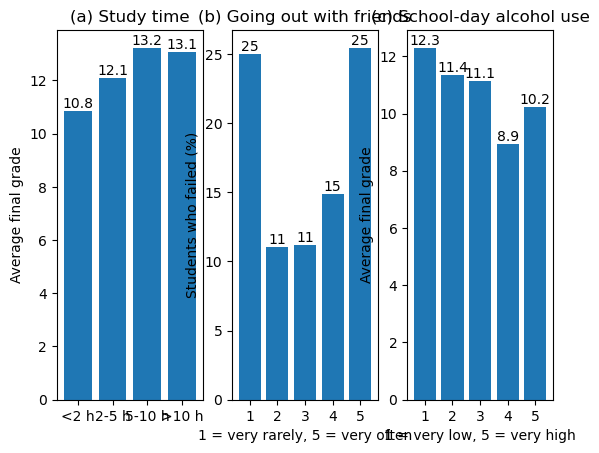

In [10]:
fig, ax = plt.subplots(1, 3)
study = df.groupby("studytime").G3.mean()
bars = ax[0].bar(["<2 h", "2-5 h", "5-10 h", ">10 h"], study.values)
ax[0].bar_label(bars, fmt="%.1f")
ax[0].set_title("(a) Study time")
ax[0].set_ylabel("Average final grade")
going = df.groupby("goout").fail.mean() * 100
bars = ax[1].bar(going.index.astype(str), going.values)
ax[1].bar_label(bars, fmt="%.0f")
ax[1].set_title("(b) Going out with friends")
ax[1].set_xlabel("1 = very rarely, 5 = very often")
ax[1].set_ylabel("Students who failed (%)")
alcohol = df.groupby("Dalc").G3.mean()
bars = ax[2].bar(alcohol.index.astype(str), alcohol.values)
ax[2].bar_label(bars, fmt="%.1f")
ax[2].set_title("(c) School-day alcohol use")
ax[2].set_xlabel("1 = very low, 5 = very high")
ax[2].set_ylabel("Average final grade")
plt.show()

In [11]:
def backward(Xm, ym, thr):
    cols = list(Xm.columns)
    while True:
        m = sm.OLS(ym, sm.add_constant(Xm[cols])).fit()
        p = m.pvalues.drop("const")
        worst = p.idxmax()
        if p[worst] > thr:
            cols.remove(worst)
        else:
            return cols


def forward(Xm, ym, thr):
    cols = []
    rest = list(Xm.columns)
    while rest:
        ps = {}
        for c in rest:
            m = sm.OLS(ym, sm.add_constant(Xm[cols + [c]])).fit()
            ps[c] = m.pvalues[c]
        best = min(ps, key=ps.get)
        if ps[best] < thr:
            cols.append(best)
            rest.remove(best)
        else:
            break
    return cols


ALPHA = 0.01
bwd = backward(Xd, y, ALPHA)
fwd = forward(Xd, y, ALPHA)
print("Backward elimination keeps", len(bwd), ":", sorted(bwd))
print("Forward selection keeps  ", len(fwd), ":", sorted(fwd))
print("Shared:", len(set(bwd) & set(fwd)), "| only backward:", sorted(set(bwd) - set(fwd)), "| only forward:", sorted(set(fwd) - set(bwd)))

Backward elimination keeps 9 : ['Dalc', 'Fedu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Forward selection keeps   9 : ['Dalc', 'Medu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Shared: 8 | only backward: ['Fedu'] | only forward: ['Medu']


## 4. Final linear model (RQ2 and RQ3)

In [12]:
ols = sm.OLS(y, sm.add_constant(Xd[bwd])).fit()
rob = sm.OLS(y, sm.add_constant(Xd[bwd])).fit(cov_type="HC3")
label = {
    "higher_yes": "Plans higher education (yes)",
    "studytime": "Weekly study time (per level)",
    "Dalc": "School-day alcohol (per level)",
    "goext": "Goes out very rarely or very often (yes)",
    "failures": "Past class failures (per failure)",
    "school_MS": "School MS (vs GP)",
    "schoolsup_yes": "Extra school support (yes)",
    "Fedu": "Father's education (per level)",
    "health": "Self-rated health (per level)",
}
role = {
    "studytime": "RQ2 habit",
    "Dalc": "RQ2 habit",
    "goext": "RQ2 habit",
    "failures": "RQ3 group",
    "school_MS": "RQ3 group",
    "higher_yes": "RQ3 group",
    "schoolsup_yes": "RQ3 group",
    "Fedu": "control",
    "health": "control",
}
coef = pd.DataFrame({"coef": rob.params, "ci_low": rob.conf_int()[0], "ci_high": rob.conf_int()[1], "p_HC3": rob.pvalues}).drop("const")
coef["role"] = coef.index.map(role)
coef.index = coef.index.map(label)
print(f"n = {int(ols.nobs)}, R2 = {ols.rsquared:.3f}, adjusted R2 = {ols.rsquared_adj:.3f}, intercept = {ols.params['const']:.2f}")
print(coef.round(3))

n = 649, R2 = 0.327, adjusted R2 = 0.317, intercept = 11.17
                                           coef  ci_low  ci_high  p_HC3  \
Father's education (per level)            0.280   0.082    0.479  0.006   
Weekly study time (per level)             0.503   0.259    0.748  0.000   
Past class failures (per failure)        -1.426  -1.831   -1.020  0.000   
School-day alcohol (per level)           -0.397  -0.676   -0.118  0.005   
Self-rated health (per level)            -0.198  -0.338   -0.058  0.006   
School MS (vs GP)                        -1.360  -1.878   -0.843  0.000   
Extra school support (yes)               -1.288  -1.965   -0.611  0.000   
Plans higher education (yes)              1.713   0.997    2.428  0.000   
Goes out very rarely or very often (yes) -0.778  -1.312   -0.243  0.004   

                                               role  
Father's education (per level)              control  
Weekly study time (per level)             RQ2 habit  
Past class failures (per fa

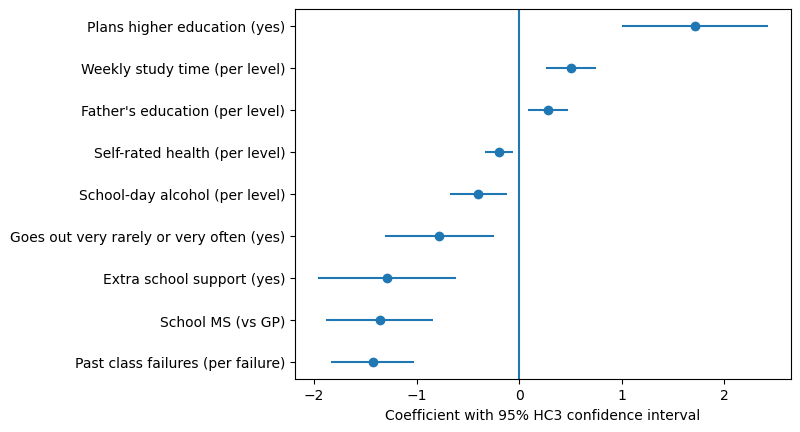

In [13]:
cp = coef.sort_values("coef")
plt.errorbar(cp.coef, range(len(cp)), xerr=[cp.coef - cp.ci_low, cp.ci_high - cp.coef], fmt="o")
plt.yticks(range(len(cp)), cp.index)
plt.axvline(0)
plt.xlabel("Coefficient with 95% HC3 confidence interval")
plt.show()

### 4.1 Fail rates by group (RQ3)

In [14]:
def group_row(name, is_comp, ref_label, comp_label):
    ref = df[~is_comp]
    comp = df[is_comp]
    row = {}
    row["group"] = name
    row["reference"] = ref_label
    row["fail_%"] = round(ref.fail.mean() * 100, 1)
    row["n"] = len(ref)
    row["comparison"] = comp_label
    row["fail_%_comp"] = round(comp.fail.mean() * 100, 1)
    row["n_comp"] = len(comp)
    return row


rows = []
rows.append(group_row("Past failures", df.failures > 0, "None", "One or more"))
rows.append(group_row("Plans higher education", df.higher == "yes", "No", "Yes"))
rows.append(group_row("School", df.school == "MS", "GP", "MS"))
gt = pd.DataFrame(rows)
print(gt)

                    group reference  fail_%    n   comparison  fail_%_comp  \
0           Past failures      None     9.3  549  One or more         49.0   
1  Plans higher education        No    47.8   69          Yes         11.6   
2                  School        GP     7.6  423           MS         30.1   

   n_comp  
0     100  
1     580  
2     226  


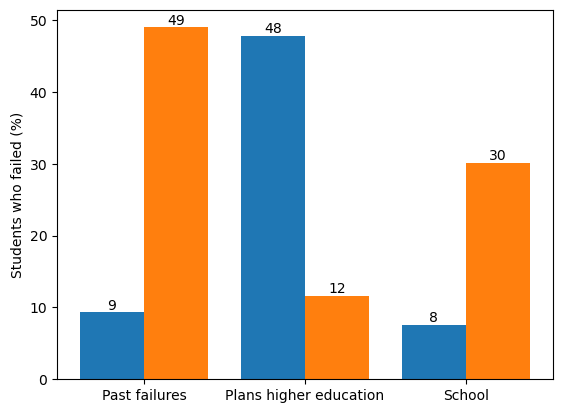

In [15]:
pos = np.arange(len(gt))
left = plt.bar(pos - 0.2, gt["fail_%"], 0.4)
right = plt.bar(pos + 0.2, gt["fail_%_comp"], 0.4)
plt.bar_label(left, fmt="%.0f")
plt.bar_label(right, fmt="%.0f")
plt.xticks(pos, gt["group"])
plt.ylabel("Students who failed (%)")
plt.show()

## 5. Assumption checks and mitigation

In [16]:
res = ols.resid
fit = ols.fittedvalues
Xc = sm.add_constant(Xd[bwd]).values
vif = []
for i in range(1, Xc.shape[1]):
    vif.append(variance_inflation_factor(Xc, i))
cooks = ols.get_influence().cooks_distance[0]
bp = het_breuschpagan(res, ols.model.exog)
sw = stats.shapiro(res)
print(f"Max VIF = {max(vif):.2f} | max Cook's D = {cooks.max():.3f} | Cook's D > 4/n: {(cooks > 4 / len(df)).sum()}")
print(f"Breusch-Pagan p = {bp[1]:.2g} | Shapiro-Wilk p = {sw.pvalue:.2g} | residual skew = {stats.skew(res):.2f}")
nz = df.G3 > 0
bp_nz = het_breuschpagan(res[nz], ols.model.exog[nz.values])
print("Residual skew without G3 = 0:", round(stats.skew(res[nz]), 2), "| BP p without G3 = 0:", f"{bp_nz[1]:.2g}")
ols_nz = sm.OLS(y[nz], sm.add_constant(Xd.loc[nz, bwd])).fit(cov_type="HC3")
cmp = pd.DataFrame({"all students": ols.params, "without G3 = 0": ols_nz.params, "p (without G3 = 0)": ols_nz.pvalues}).drop("const")
cmp.index = cmp.index.map(label)
print(cmp.round(3))
print("R2 without zeros:", round(ols_nz.rsquared, 3))

Max VIF = 1.19 | max Cook's D = 0.044 | Cook's D > 4/n: 37
Breusch-Pagan p = 2e-05 | Shapiro-Wilk p = 5.7e-13 | residual skew = -0.71
Residual skew without G3 = 0: 0.22 | BP p without G3 = 0: 0.27
                                          all students  without G3 = 0  \
Father's education (per level)                   0.280           0.231   
Weekly study time (per level)                    0.503           0.452   
Past class failures (per failure)               -1.426          -1.227   
School-day alcohol (per level)                  -0.397          -0.353   
Self-rated health (per level)                   -0.198          -0.158   
School MS (vs GP)                               -1.360          -0.838   
Extra school support (yes)                      -1.288          -1.244   
Plans higher education (yes)                     1.713           1.688   
Goes out very rarely or very often (yes)        -0.778          -0.446   

                                          p (without G3 = 0)  

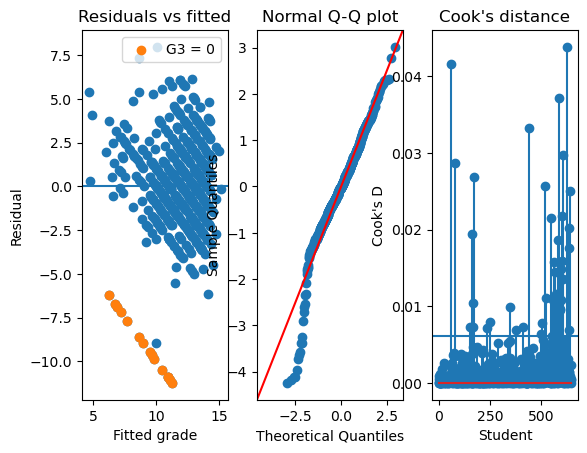

In [17]:
zeros = df.G3 == 0
fig, ax = plt.subplots(1, 3)
ax[0].scatter(fit, res)
ax[0].scatter(fit[zeros], res[zeros], label="G3 = 0")
ax[0].axhline(0)
ax[0].set_title("Residuals vs fitted")
ax[0].set_xlabel("Fitted grade")
ax[0].set_ylabel("Residual")
ax[0].legend()
sm.qqplot(res, line="45", fit=True, ax=ax[1])
ax[1].set_title("Normal Q-Q plot")
ax[2].stem(cooks)
ax[2].axhline(4 / len(df))
ax[2].set_title("Cook's distance")
ax[2].set_xlabel("Student")
ax[2].set_ylabel("Cook's D")
plt.show()

### 5.1 Out-of-sample check

In [18]:
def r2f(yt, p):
    return 1 - ((yt - p) ** 2).sum() / ((yt - yt.mean()) ** 2).sum()


p_sel = np.zeros(len(df))
p_all = np.zeros(len(df))
p_fix = np.zeros(len(df))
for train, test in KFold(10, shuffle=True, random_state=RNG).split(Xd):
    cols = backward(Xd.iloc[train], y.iloc[train], ALPHA)
    p_sel[test] = LinearRegression().fit(Xd.iloc[train][cols], y.iloc[train]).predict(Xd.iloc[test][cols])
    p_all[test] = LinearRegression().fit(Xd.iloc[train], y.iloc[train]).predict(Xd.iloc[test])
    p_fix[test] = LinearRegression().fit(Xd.iloc[train][bwd], y.iloc[train]).predict(Xd.iloc[test][bwd])
cv = {
    "selection repeated in each fold": p_sel,
    "all 40 candidates": p_all,
    "9 chosen variables (selection outside CV)": p_fix,
}
for name, p in cv.items():
    print(f"{name}: CV R2 = {r2f(y, p):.3f}, RMSE = {np.sqrt(((y - p) ** 2).mean()):.2f}")

selection repeated in each fold: CV R2 = 0.264, RMSE = 2.77
all 40 candidates: CV R2 = 0.277, RMSE = 2.75
9 chosen variables (selection outside CV): CV R2 = 0.304, RMSE = 2.69
